# Import and eval functions

In [14]:
%load_ext autoreload
%autoreload 2

import os, sys, h5py, gc, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
import concurrent.futures as cf
from pathlib import Path
from torch.utils.data import DataLoader

REPO_ROOT = "./"
proj = Path(REPO_ROOT).resolve()

# allow: import ADCNN.*
sys.path.insert(0, str(proj))

# allow: import utils.*  (where utils == ADCNN/utils)
sys.path.insert(0, str(proj / "ADCNN"))

import ADCNN.inference.postprocess as postprocess
from ADCNN.data.datasets import H5TiledDataset
from ADCNN.inference.predict import load_model, predict_tiles_to_full
from ADCNN.inference.postprocess import postprocess_prediction, postprocess_predictions
import ADCNN.evaluation.detection as evals
import ADCNN.evaluation.threshold_scan as threshold_scan

MODEL_CKPT = "./checkpoints/ckpt_last.pt"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
def calculate_model_metrics (catalog, predictions, ground_truth, thr_points=100, stack_fp=None, best_threshold=None):
    catalog = catalog.copy()
    if best_threshold is None:
        threshold_df = threshold_scan.scan_thresholds(catalog=catalog, predictions=predictions, ground_truth=ground_truth, stack_fp=stack_fp, n_points=thr_points)
        threshold_scan.plot_fscore(threshold_df["thr"], pix_f1=threshold_df.get("pix_f1"), pix_f2=threshold_df.get("pix_f2"),
                               obj_f1=threshold_df.get("obj_f1"), obj_f2=threshold_df.get("obj_f2"), title="Pixelwise vs Objectwise F-scores")
        threshold_scan.plot_roc(threshold_scan.compute_roc(threshold_df["pix_tp"], threshold_df["pix_fp"], threshold_df["pix_tn"], threshold_df["pix_fn"]))
        threshold_scan.plot_froc(threshold_scan.compute_froc(thr=threshold_df["thr"], obj_tp=threshold_df["obj_tp"], obj_fp=threshold_df["obj_fp"], obj_fn=threshold_df["obj_fn"], n_images=50),
                             title="FROC (objectwise)")
        best_threshold = threshold_df["thr"][threshold_df["obj_f2"].argmax()]
    _,_,catalog = evals.full_confusion(catalog=catalog, ground_truth= ground_truth,predictions=predictions, stack_fp=stack_fp, threshold=best_threshold, verbose=True)
    _ = evals.combined_confusion_separate(catalog=test_catalog, ground_truth=ground_truth, predictions=predictions, threshold=best_threshold, verbose=True, stack_mask=stack_fp)
    _ = evals.plot_detect_hist(catalog, "PSF_mag", bins=12, title="NN detections vs PSF_mag threshold=" + str(round(best_threshold, 3)))
    _ = evals.plot_detect_hist(catalog, "trail_length", bins=12, title="Detections vs trail length threshold="+ str(round(best_threshold, 3)))
    _ = evals.plot_detect_hist(catalog, "SNR", bins=10, title="Detections vs SNR threshold="+ str(round(best_threshold, 3)), xlim=[0, 10], density=True)
    _ = evals.plot_completeness_2d(catalog, snr_bins=10, trail_bins=10, title="Model completeness")
    _ = evals.plot_completeness_2d(catalog, snr_bins=10, trail_bins=10, detected=(~catalog["stack_detection"].values.astype(bool) & catalog["nn_detected"].values.astype(bool)),
                                   title="Model detection but not stack detection")
    plt.show()
    return catalog

def get_stack_metrics (catalog, fp_mask):
    tp = (catalog["stack_detection"]==True).sum()
    fn = (catalog["stack_detection"]==False).sum()
    fp = fp_mask.max(axis=(1, 2)).sum()
    return  {"TP": tp, "FP": fp, "FN": fn, "TN": pd.NA}

# 5 sigma threshold

In [16]:
test_h5 = "./DATA/test.h5"
test_csv = "./DATA/test.csv"

ds_te = H5TiledDataset(test_h5,  tile=128, k_sigma=5.0)

test_loader = DataLoader(
    ds_te,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=None,
)

test_catalog = pd.read_csv(test_csv)
with h5py.File(test_h5, "r") as _f:
    gt_test = _f["masks"][:].astype(np.uint8)
    stack_fp = _f["real_labels"][:].astype(np.uint16)
print("Test tiles:", len(ds_te))

Test tiles: 51200


## LSST stack

Object-wise Confusion Matrix
F1 Score: 0.0090, F2 Score: 0.0219
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              127210
Actual Positive                 422                 578



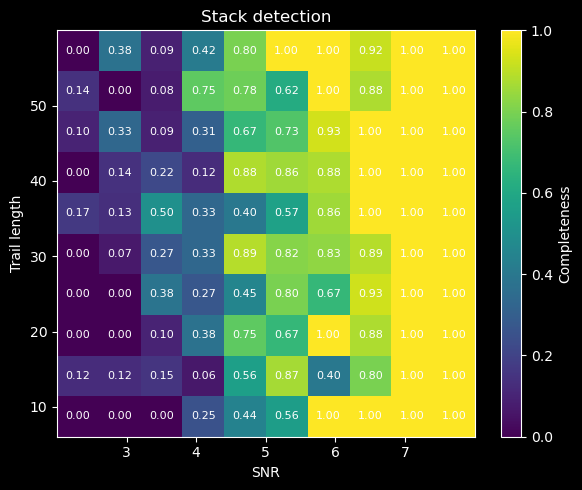

In [17]:
evals.print_confusion_matrix(get_stack_metrics (test_catalog, stack_fp), title="Object-wise Confusion Matrix")
_ = evals.plot_completeness_2d(test_catalog, snr_bins=10, trail_bins=10, detected=test_catalog["stack_detection"].values.astype(bool), title="Stack detection")
plt.show()

## Model

In [18]:
model = load_model(MODEL_CKPT)
p = predict_tiles_to_full(test_h5, test_loader, model, tile=128)
model.to('cpu')
gc.collect()
torch.cuda.empty_cache()
print("Predictions shape:", p.shape)

Loaded model from: ./checkpoints/ckpt_last.pt
Predictions shape: (50, 4004, 4096)


### Best threshold

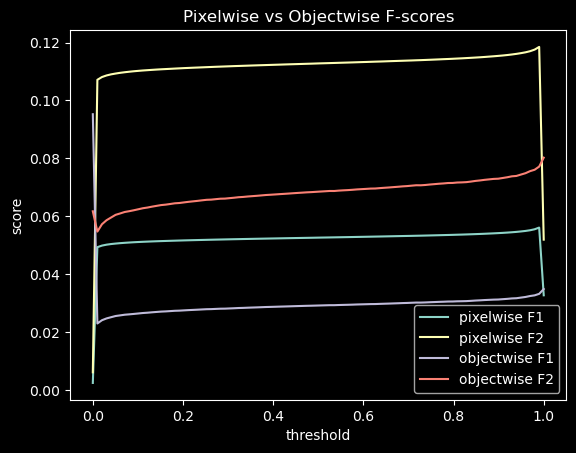

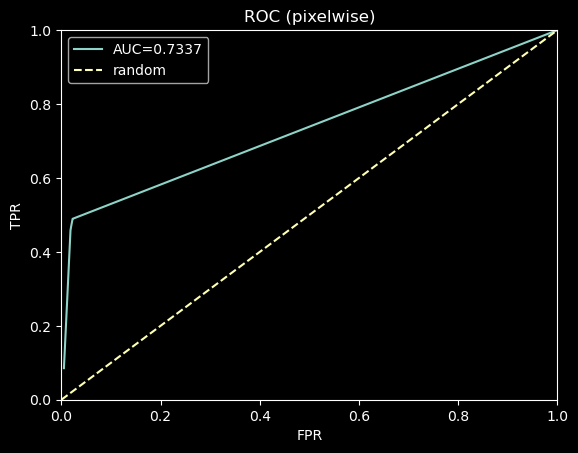

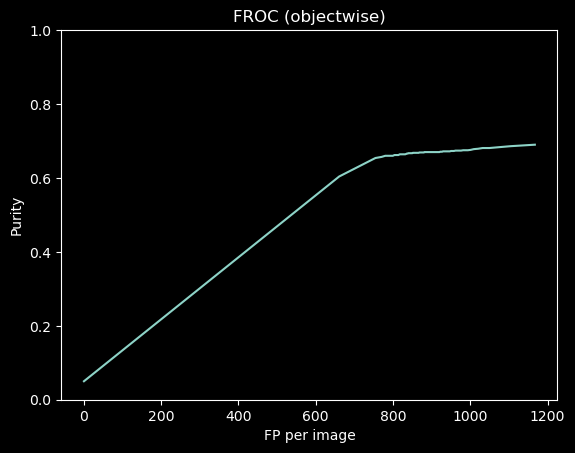

Object-level Confusion Matrix
F1 Score: 0.0355, F2 Score: 0.0815
                 Predicted Negative  Predicted Positive
Actual Negative                   0               32468
Actual Positive                 396                 604

Pixel-level Confusion Matrix
F1 Score: 0.0327, F2 Score: 0.0519
                 Predicted Negative  Predicted Positive
Actual Negative           814840419             4170173
Actual Positive              922489               86119

Combined Object-level Confusion Matrix
F1 Score: 0.0092, F2 Score: 0.0227
                 Predicted Negative  Predicted Positive
Actual Negative                   0              159678
Actual Positive                 254                 746



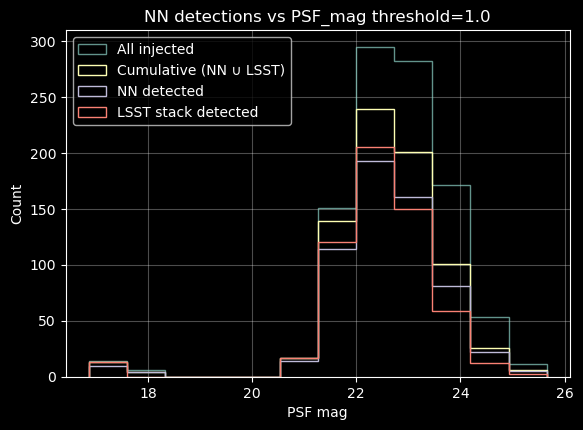

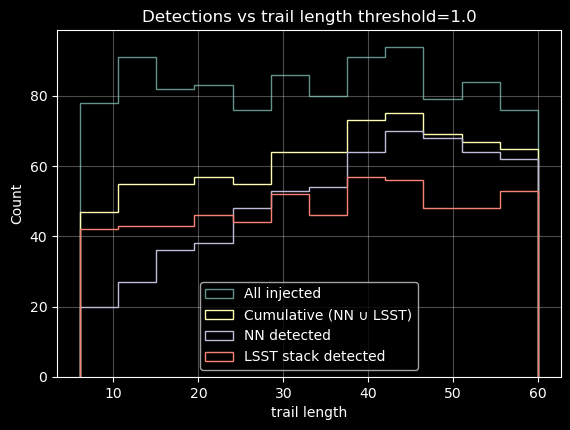

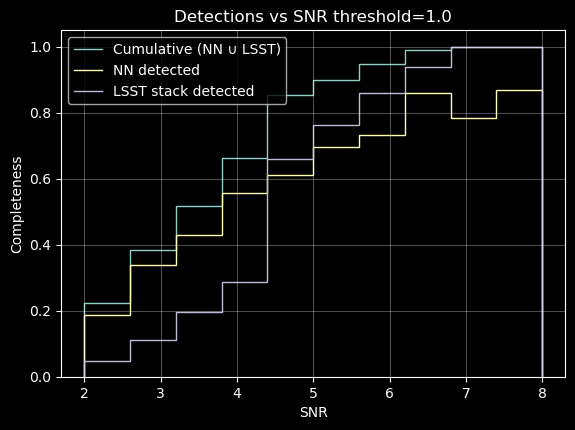

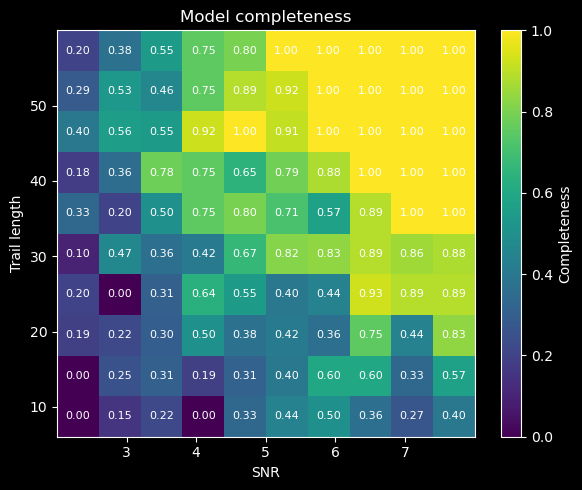

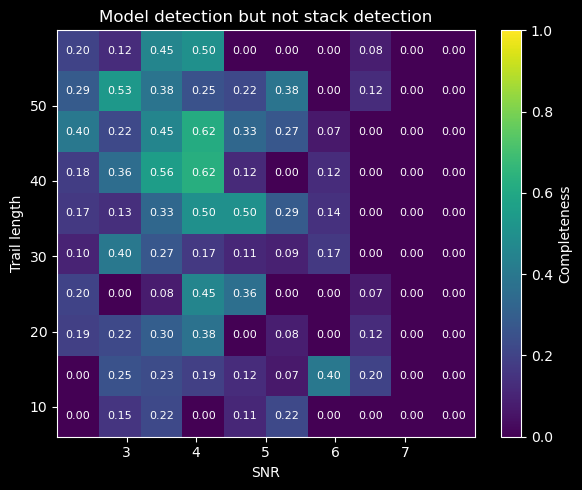

In [19]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp)

### 0.5 Threshold

Object-level Confusion Matrix
F1 Score: 0.0292, F2 Score: 0.0685
                 Predicted Negative  Predicted Positive
Actual Negative                   0               44215
Actual Positive                 330                 670

Pixel-level Confusion Matrix
F1 Score: 0.0526, F2 Score: 0.1128
                 Predicted Negative  Predicted Positive
Actual Negative           802329996            16680596
Actual Positive              530547              478061

Combined Object-level Confusion Matrix
F1 Score: 0.0091, F2 Score: 0.0224
                 Predicted Negative  Predicted Positive
Actual Negative                   0              171425
Actual Positive                 210                 790



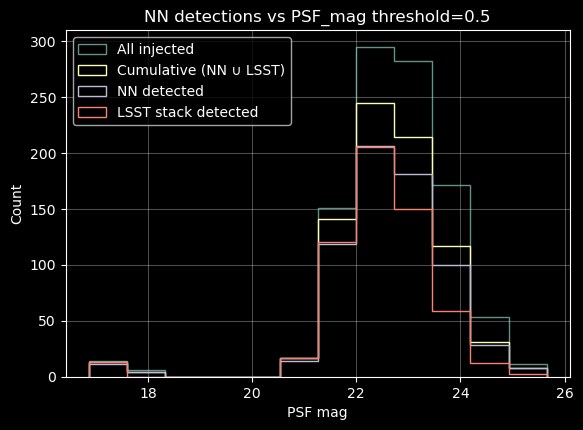

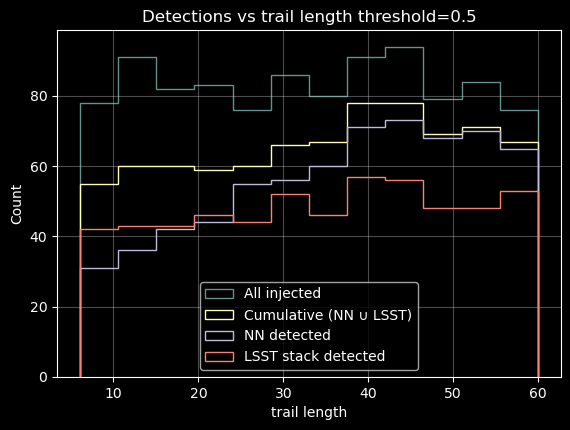

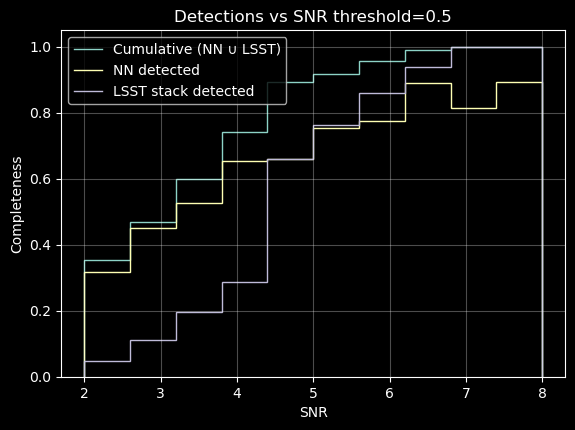

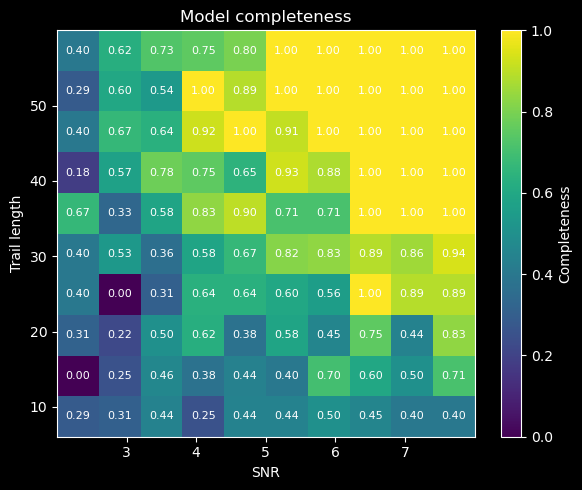

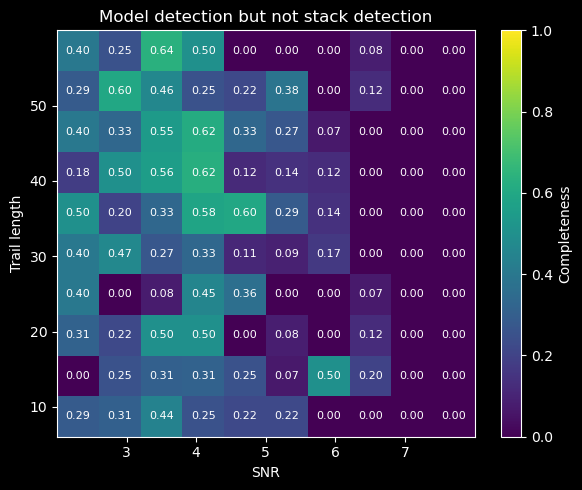

In [20]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp, best_threshold=0.5)

### Two stage classifier

Object-level Confusion Matrix
F1 Score: 0.0321, F2 Score: 0.0749
                 Predicted Negative  Predicted Positive
Actual Negative                   0               39852
Actual Positive                 333                 667

Pixel-level Confusion Matrix
F1 Score: 0.0517, F2 Score: 0.1112
                 Predicted Negative  Predicted Positive
Actual Negative           801838927            17171665
Actual Positive              526243              482365

Combined Object-level Confusion Matrix
F1 Score: 0.0093, F2 Score: 0.0229
                 Predicted Negative  Predicted Positive
Actual Negative                   0              167062
Actual Positive                 213                 787



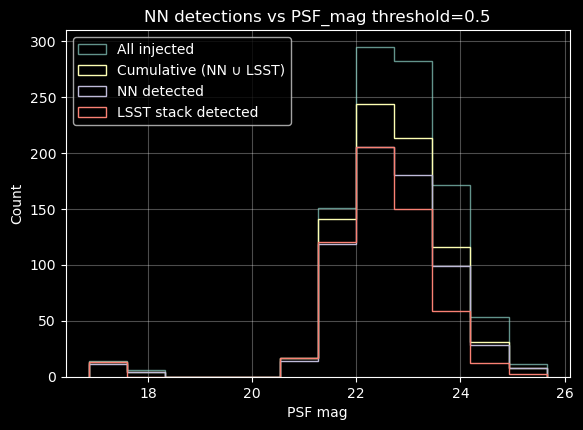

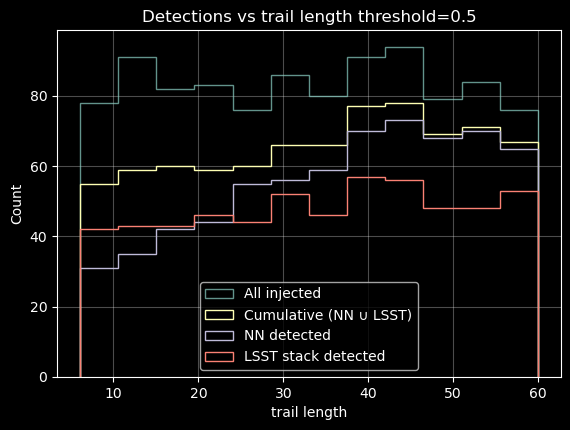

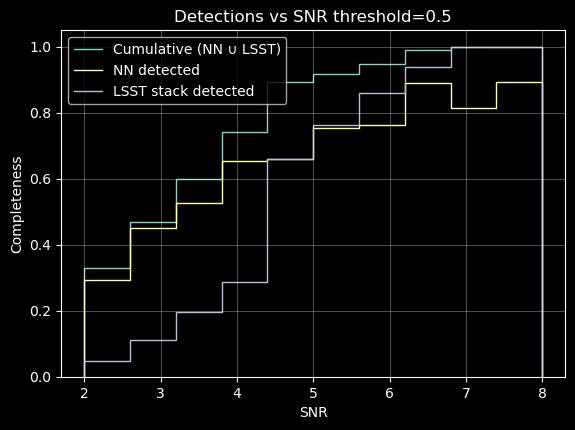

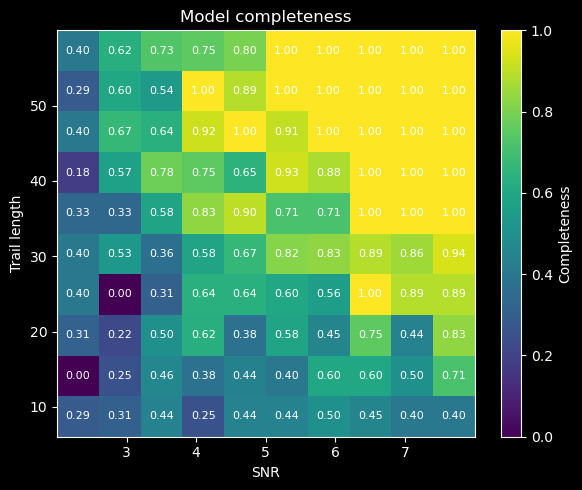

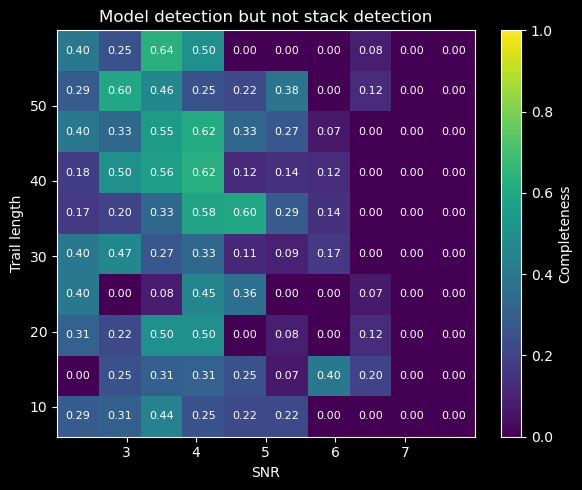

In [21]:
masks, detections = postprocess_predictions(predictions=p, return_label_mask=True)
__ = calculate_model_metrics(test_catalog, masks, gt_test, stack_fp=stack_fp, best_threshold=0.5)

# 4 sigma threshold

In [22]:
test_h5 = "./DATA/test_SNR4.h5"
test_csv = "./DATA/test_SNR4.csv"

ds_te = H5TiledDataset(test_h5,  tile=128, k_sigma=5.0)

test_loader = DataLoader(
    ds_te,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=None,
)

test_catalog = pd.read_csv(test_csv)
with h5py.File(test_h5, "r") as _f:
    gt_test = _f["masks"][:].astype(np.uint8)
    stack_fp = _f["real_labels"][:].astype(np.uint16)
print("Test tiles:", len(ds_te))

Test tiles: 51200


## LSST stack

Object-wise Confusion Matrix
F1 Score: 0.0093, F2 Score: 0.0227
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              162593
Actual Positive                 239                 761



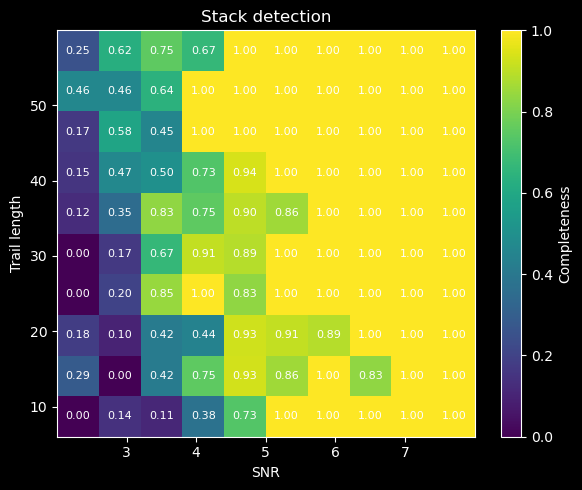

In [23]:
evals.print_confusion_matrix(get_stack_metrics (test_catalog, stack_fp), title="Object-wise Confusion Matrix")
_ = evals.plot_completeness_2d(test_catalog, snr_bins=10, trail_bins=10, detected=test_catalog["stack_detection"].values.astype(bool), title="Stack detection")
plt.show()

## Model

In [24]:
model = load_model(MODEL_CKPT)
p = predict_tiles_to_full(test_h5, test_loader, model, tile=128)
model.to('cpu')
gc.collect()
torch.cuda.empty_cache()
print("Predictions shape:", p.shape)

Loaded model from: ./checkpoints/ckpt_last.pt
Predictions shape: (50, 4004, 4096)


### Best threshold

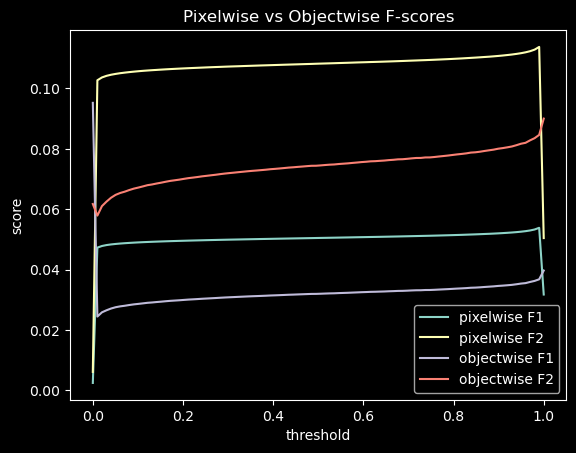

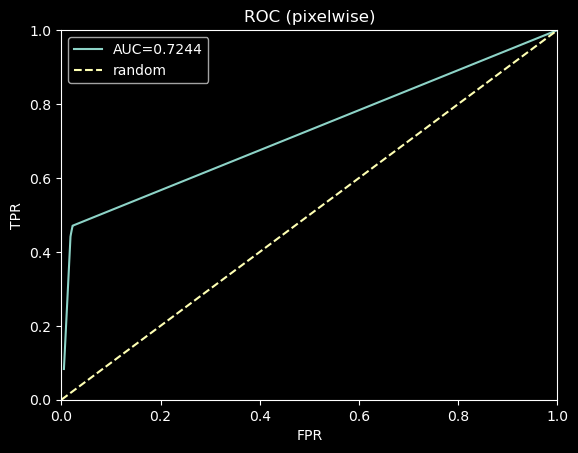

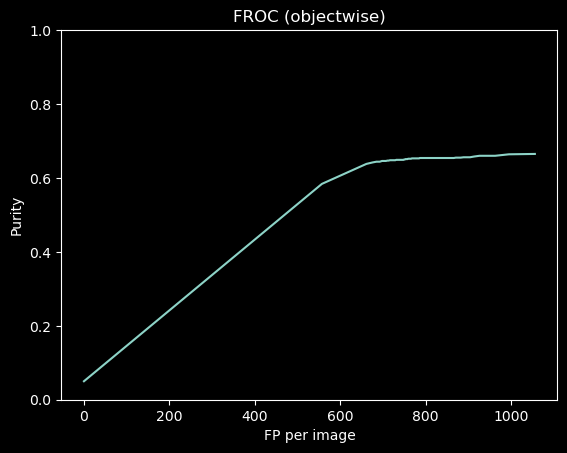

Object-level Confusion Matrix
F1 Score: 0.0404, F2 Score: 0.0915
                 Predicted Negative  Predicted Positive
Actual Negative                   0               27335
Actual Positive                 416                 584

Pixel-level Confusion Matrix
F1 Score: 0.0317, F2 Score: 0.0504
                 Predicted Negative  Predicted Positive
Actual Negative           814847839             4168135
Actual Positive              919859               83367

Combined Object-level Confusion Matrix
F1 Score: 0.0085, F2 Score: 0.0209
                 Predicted Negative  Predicted Positive
Actual Negative                   0              189928
Actual Positive                 185                 815



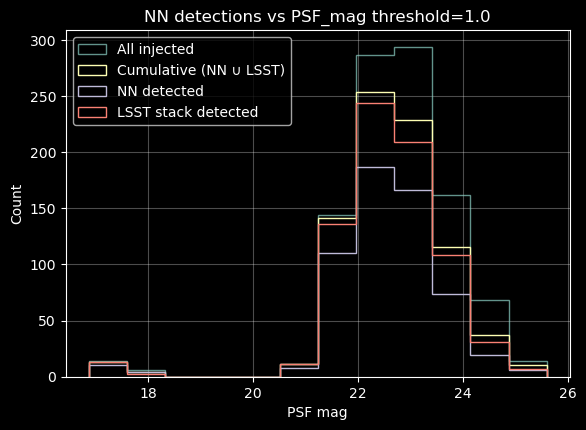

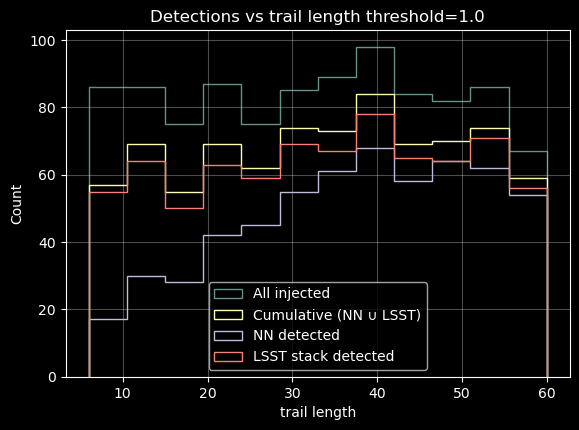

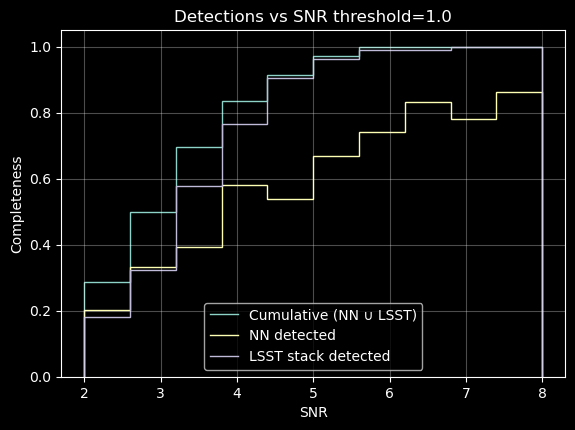

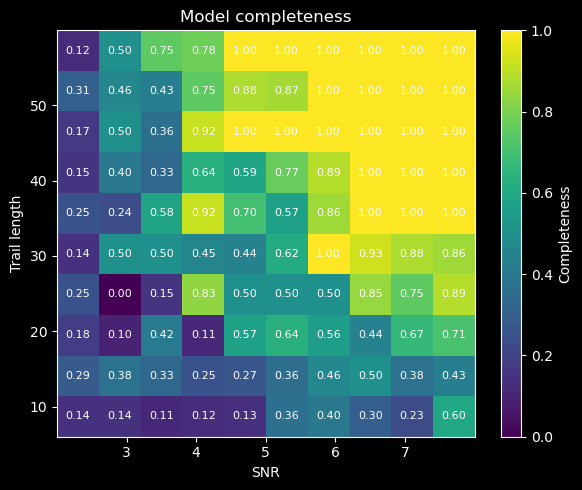

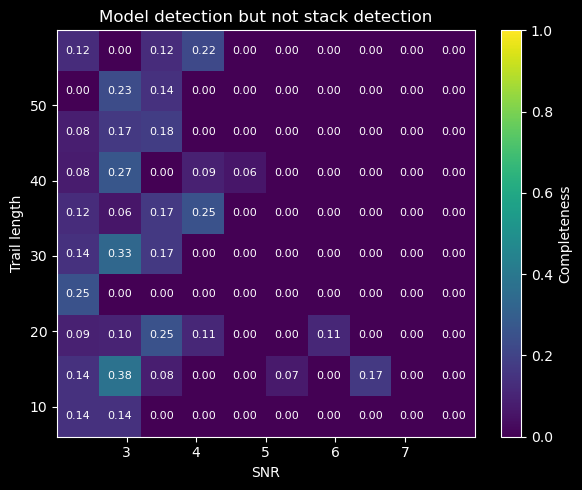

In [25]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp)

### 0.5 threshold

Object-level Confusion Matrix
F1 Score: 0.0320, F2 Score: 0.0745
                 Predicted Negative  Predicted Positive
Actual Negative                   0               39177
Actual Positive                 347                 653

Pixel-level Confusion Matrix
F1 Score: 0.0505, F2 Score: 0.1082
                 Predicted Negative  Predicted Positive
Actual Negative           802342699            16673275
Actual Positive              545591              457635

Combined Object-level Confusion Matrix
F1 Score: 0.0083, F2 Score: 0.0204
                 Predicted Negative  Predicted Positive
Actual Negative                   0              201770
Actual Positive                 158                 842



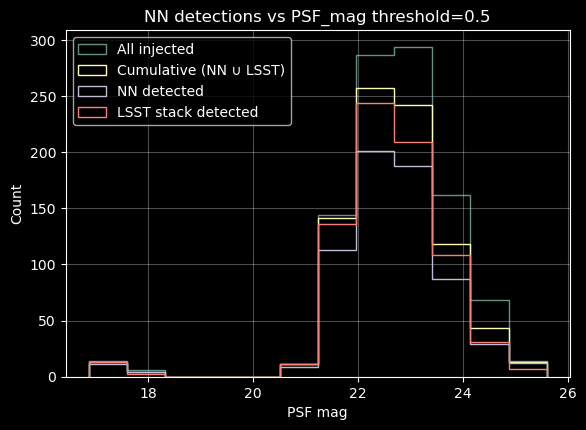

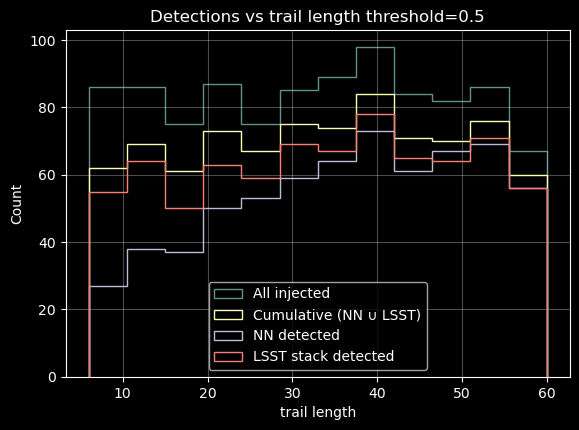

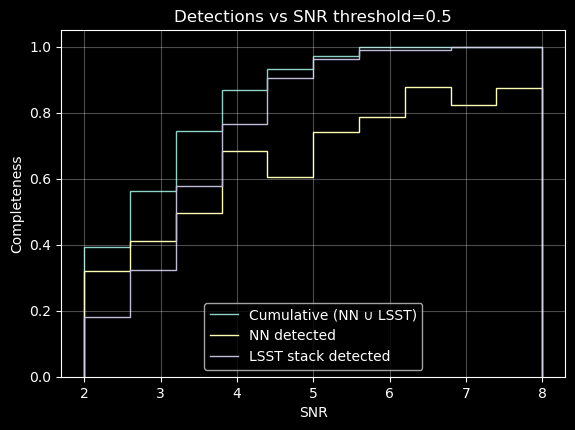

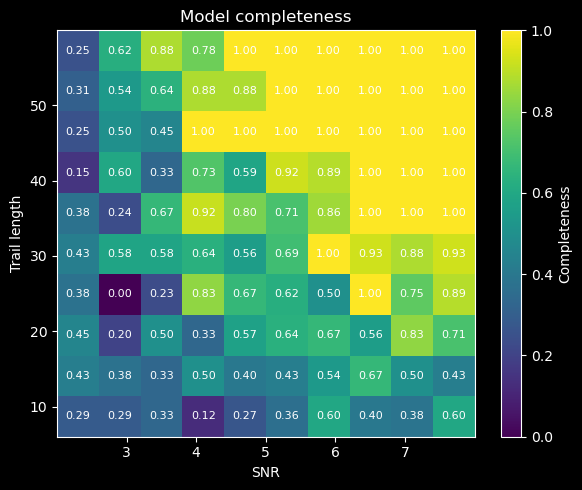

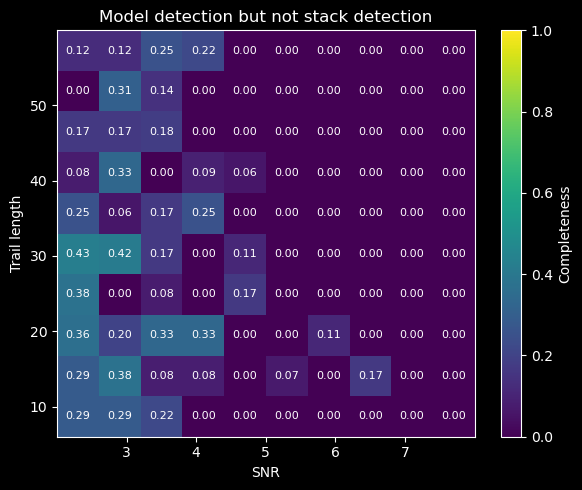

In [26]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp, best_threshold=0.5)

### Two stage classifier

Object-level Confusion Matrix
F1 Score: 0.0357, F2 Score: 0.0824
                 Predicted Negative  Predicted Positive
Actual Negative                   0               34908
Actual Positive                 348                 652

Pixel-level Confusion Matrix
F1 Score: 0.0496, F2 Score: 0.1067
                 Predicted Negative  Predicted Positive
Actual Negative           801851324            17164650
Actual Positive              541487              461739

Combined Object-level Confusion Matrix
F1 Score: 0.0084, F2 Score: 0.0208
                 Predicted Negative  Predicted Positive
Actual Negative                   0              197501
Actual Positive                 158                 842



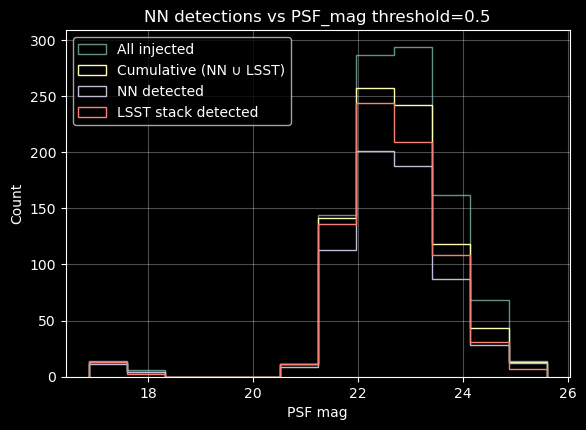

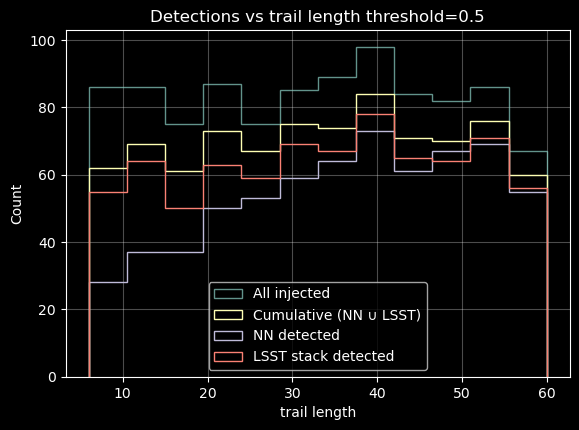

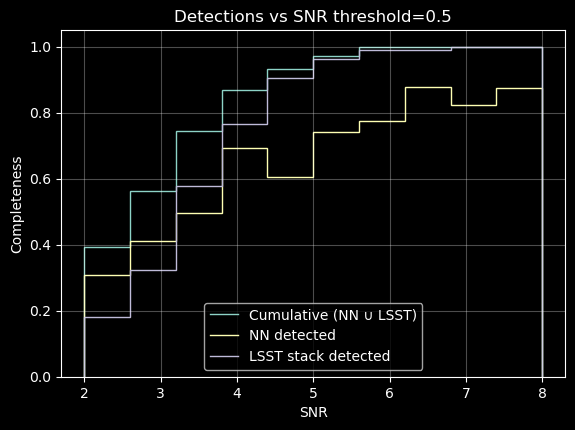

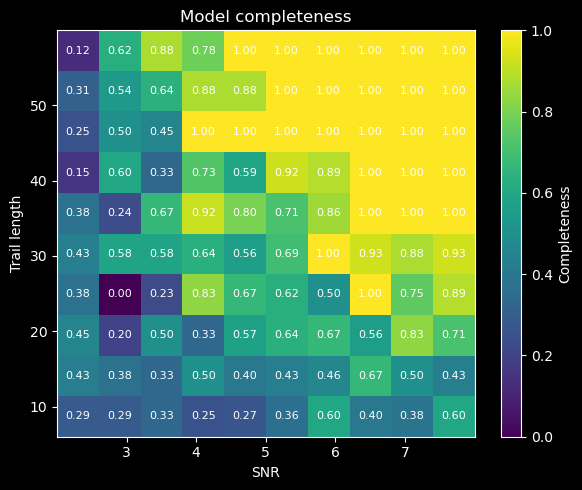

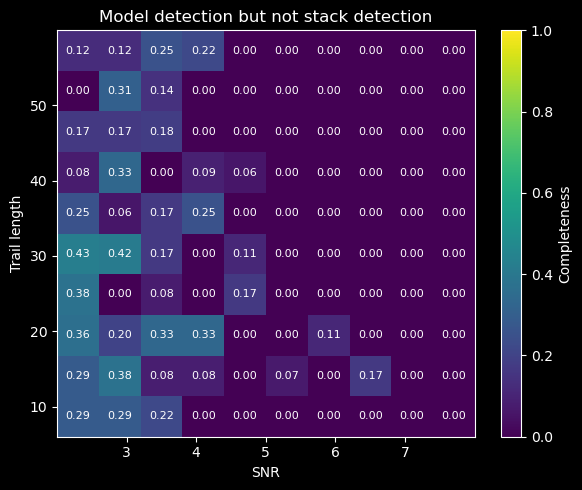

In [27]:
masks, detections = postprocess_predictions(predictions=p, return_label_mask=True)
__ = calculate_model_metrics(test_catalog, masks, gt_test, stack_fp=stack_fp, best_threshold=0.5)

# 3 sigma threshold

In [28]:
test_h5 = "./DATA/test_SNR3.h5"
test_csv = "./DATA/test_SNR3.csv"

ds_te = H5TiledDataset(test_h5,  tile=128, k_sigma=5.0)

test_loader = DataLoader(
    ds_te,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=None,
)

test_catalog = pd.read_csv(test_csv)
with h5py.File(test_h5, "r") as _f:
    gt_test = _f["masks"][:].astype(np.uint8)
    stack_fp = _f["real_labels"][:].astype(np.uint16)
print("Test tiles:", len(ds_te))

Test tiles: 51200


## LSST stack

Object-wise Confusion Matrix
F1 Score: 0.0061, F2 Score: 0.0151
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              293413
Actual Positive                 102                 898



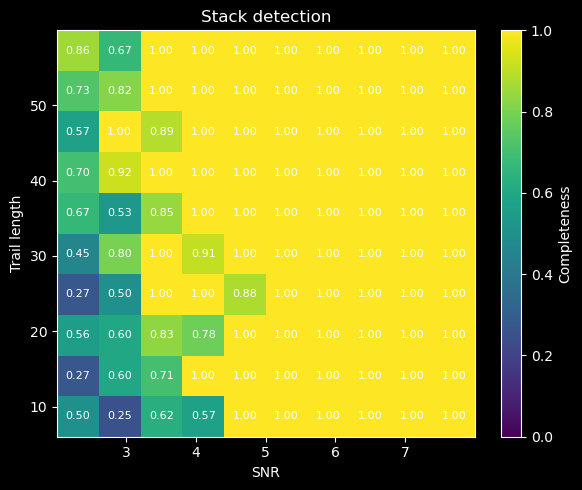

In [29]:
evals.print_confusion_matrix(get_stack_metrics (test_catalog, stack_fp), title="Object-wise Confusion Matrix")
_ = evals.plot_completeness_2d(test_catalog, snr_bins=10, trail_bins=10, detected=test_catalog["stack_detection"].values.astype(bool), title="Stack detection")

## Model

In [30]:
model = load_model(MODEL_CKPT)
p = predict_tiles_to_full(test_h5, test_loader, model, tile=128)
model.to('cpu')
gc.collect()
torch.cuda.empty_cache()
print("Predictions shape:", p.shape)

Loaded model from: ./checkpoints/ckpt_last.pt
Predictions shape: (50, 4004, 4096)


### Best threshold

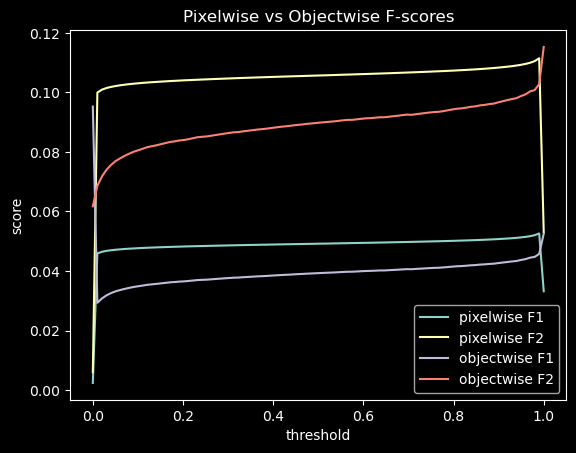

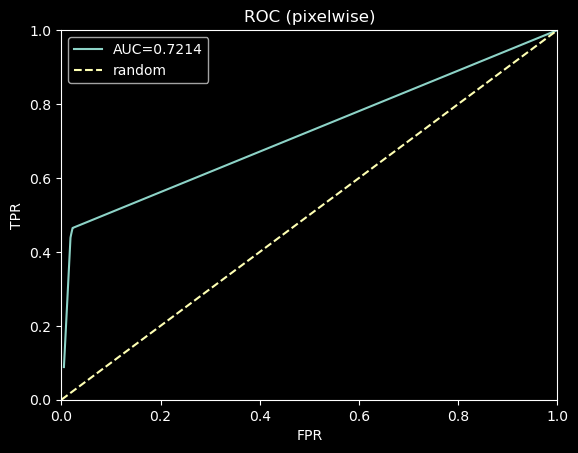

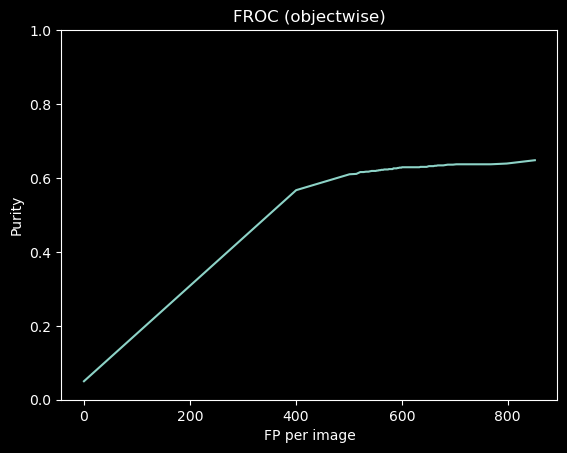

Object-level Confusion Matrix
F1 Score: 0.0537, F2 Score: 0.1176
                 Predicted Negative  Predicted Positive
Actual Negative                   0               19534
Actual Positive                 433                 567

Pixel-level Confusion Matrix
F1 Score: 0.0332, F2 Score: 0.0531
                 Predicted Negative  Predicted Positive
Actual Negative           814861589             4172395
Actual Positive              898182               87034

Combined Object-level Confusion Matrix
F1 Score: 0.0058, F2 Score: 0.0143
                 Predicted Negative  Predicted Positive
Actual Negative                   0              312947
Actual Positive                  93                 907



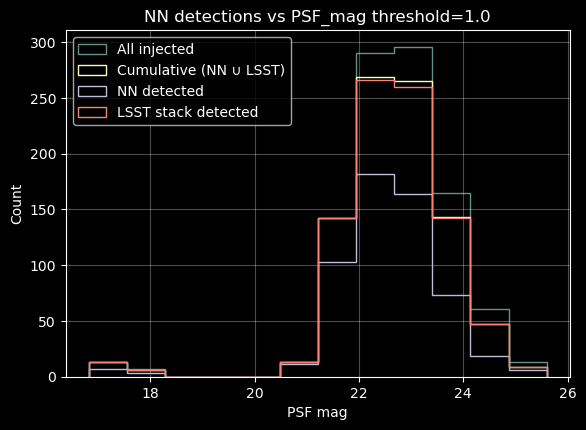

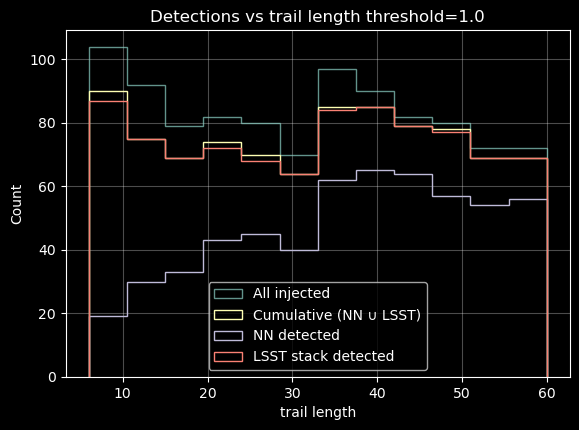

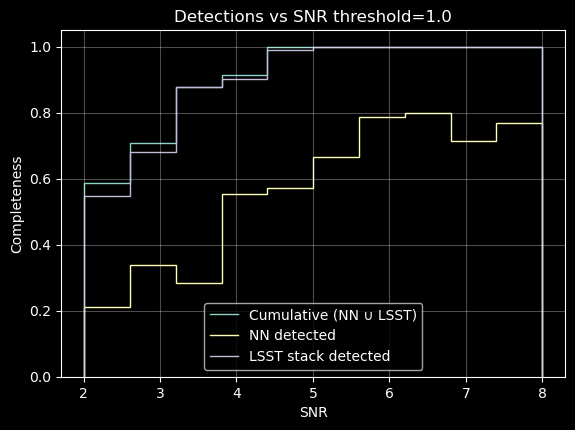

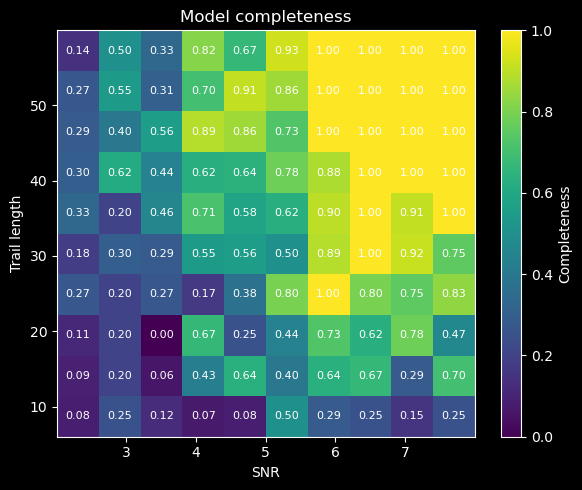

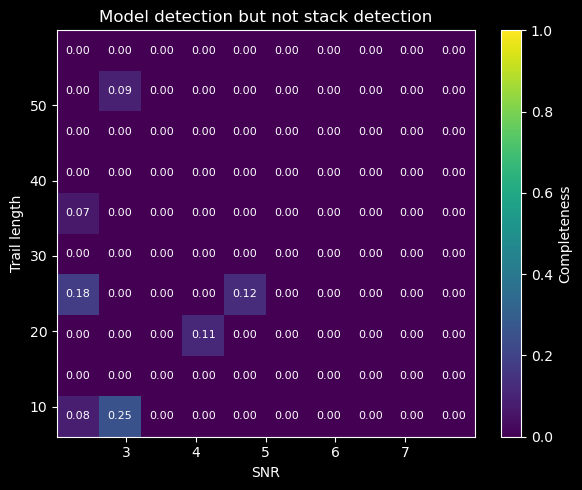

In [31]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp)

### 0.5 Threshold

Object-level Confusion Matrix
F1 Score: 0.0393, F2 Score: 0.0898
                 Predicted Negative  Predicted Positive
Actual Negative                   0               30374
Actual Positive                 371                 629

Pixel-level Confusion Matrix
F1 Score: 0.0492, F2 Score: 0.1057
                 Predicted Negative  Predicted Positive
Actual Negative           802362155            16671829
Actual Positive              540217              444999

Combined Object-level Confusion Matrix
F1 Score: 0.0056, F2 Score: 0.0139
                 Predicted Negative  Predicted Positive
Actual Negative                   0              323787
Actual Positive                  85                 915



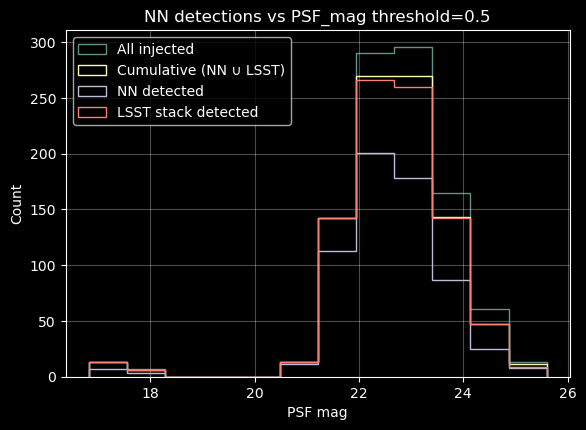

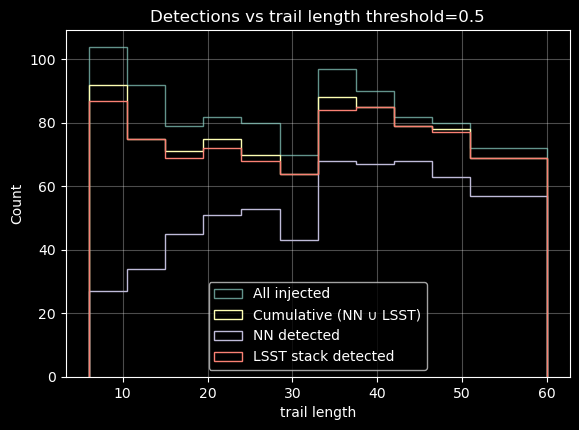

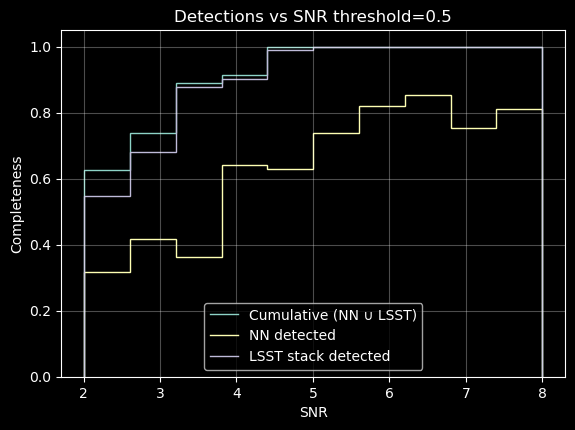

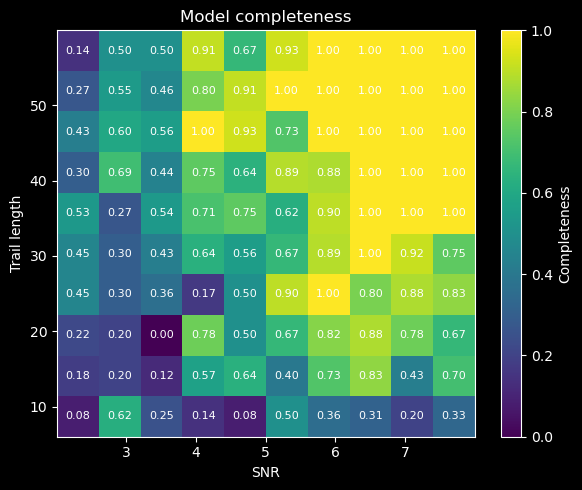

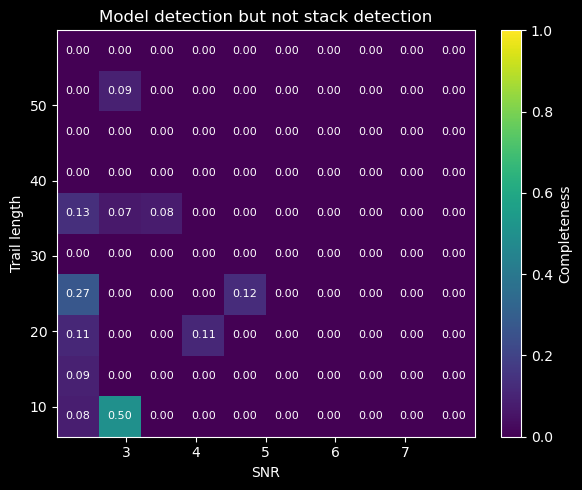

In [32]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp, best_threshold=0.5)

### Two stage classifier

Object-level Confusion Matrix
F1 Score: 0.0447, F2 Score: 0.1009
                 Predicted Negative  Predicted Positive
Actual Negative                   0               26391
Actual Positive                 374                 626

Pixel-level Confusion Matrix
F1 Score: 0.0482, F2 Score: 0.1041
                 Predicted Negative  Predicted Positive
Actual Negative           801871071            17162913
Actual Positive              536594              448622

Combined Object-level Confusion Matrix
F1 Score: 0.0057, F2 Score: 0.0141
                 Predicted Negative  Predicted Positive
Actual Negative                   0              319804
Actual Positive                  85                 915



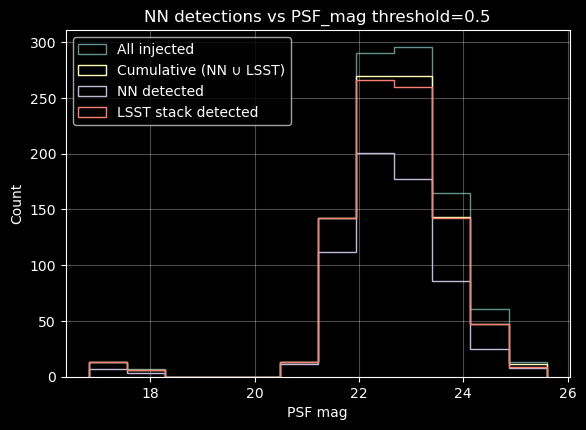

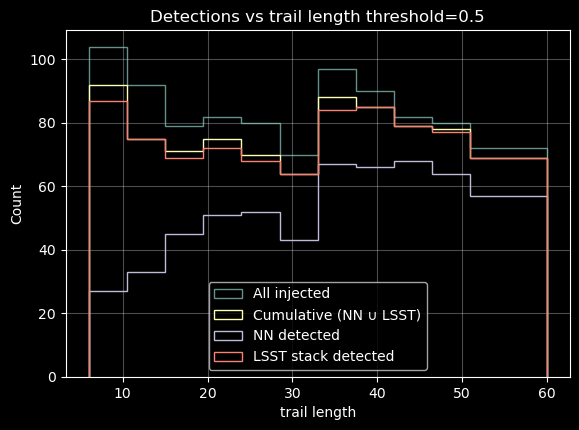

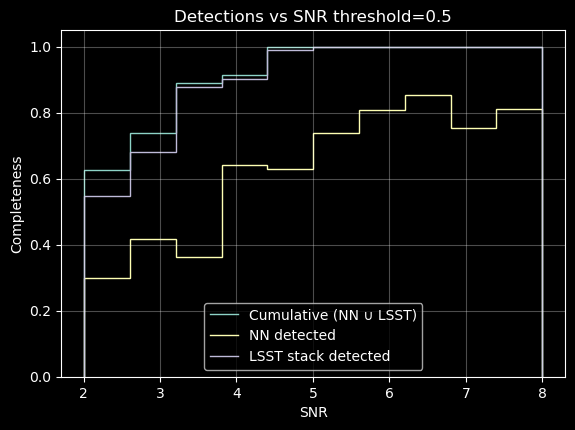

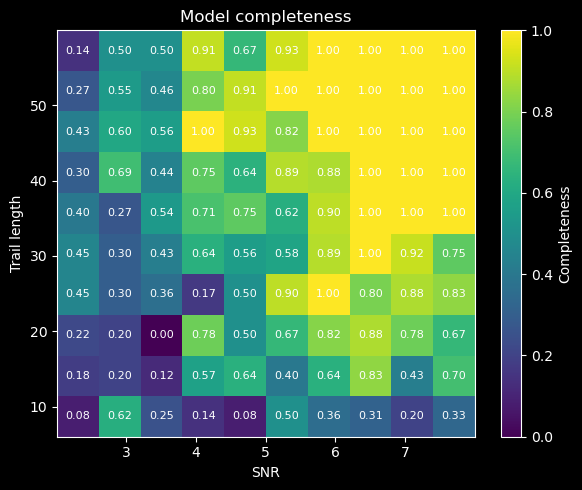

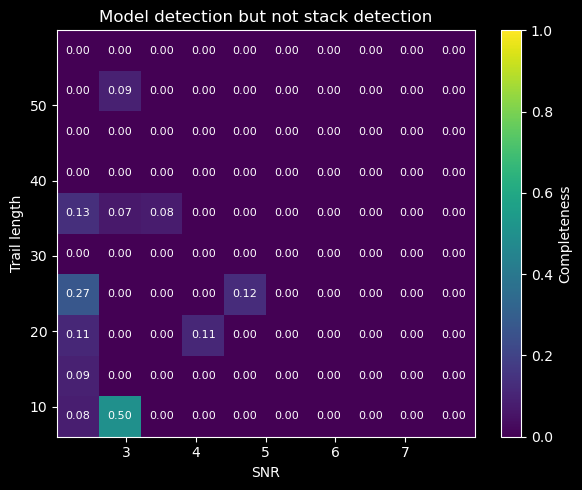

In [33]:
masks, detections = postprocess_predictions(predictions=p, return_label_mask=True)
__ = calculate_model_metrics(test_catalog, masks, gt_test, stack_fp=stack_fp, best_threshold=0.5)

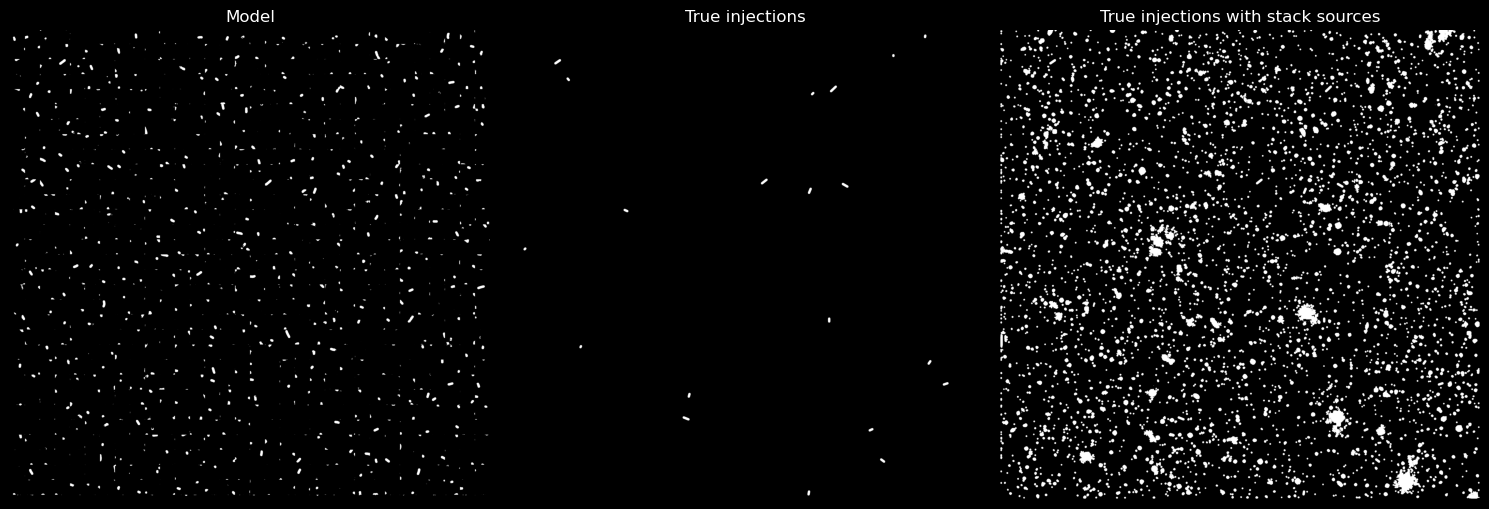

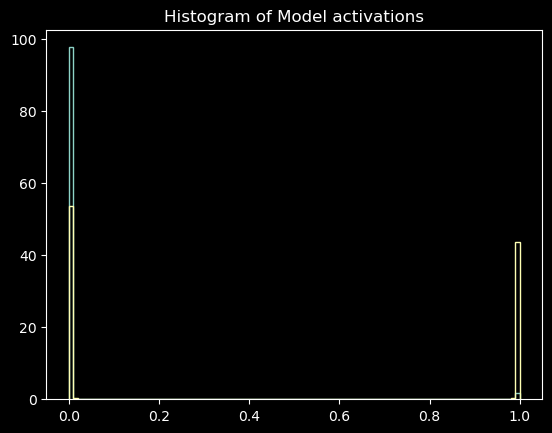

In [34]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(p[0], cmap='gray', vmin=0, vmax=1)
ax[0].axis('off')
ax[0].set_title("Model")
ax[1].imshow((gt_test[0]), cmap='gray', vmin=0, vmax=1)
ax[1].axis('off')
ax[1].set_title("True injections")
ax[2].imshow((gt_test[0] | (stack_fp[0] > 0.5)), cmap='gray', vmin=0, vmax=1)
ax[2].axis('off')
ax[2].set_title("True injections with stack sources")
fig.tight_layout()
plt.show()
plt.hist(p[gt_test<0.5].flatten(), density=True, bins=100, histtype='step')
plt.hist(p[gt_test>0.5].flatten(), density=True, bins=100, histtype='step')
plt.title("Histogram of Model activations")
plt.show()